# Project: EDA of Titanic Dataset
The RMS Titanic was a British passenger liner that sank in the North Atlantic Ocean in the early morning hours of 15 April 1912, after it collided with an iceberg during its maiden voyage from Southampton to New York City. 

### 1. Problem Definition:
How can we comprehend the connections between the many passenger attributes in the dataset (such as age, gender, class, etc.) and their likelihood of surviving the incident? Finding correlations within the dataset is the goal of this EDA.

### 2. Data description:
The dataset consist 1309 entries with four (4) different columns: Unnamed: 0, sex, age and passengerClass.

### 3. Approach:
* Examine the data for missing values
* Analyze the relationship between features



# Import necessary libraries

In [1]:
import numpy as np # for numerical computation
import pandas as pd # for data manipulation
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns

''' magic command that ensures matplotlib plots 
are displayed directly inside the Jupyter Notebook cells '''
%matplotlib inline 

In [2]:
# define a variable to store the dataframe
data = pd.read_csv('Titanic.csv')

In [3]:
# print the dataframe to the console
data

,Unnamed: 0,survived,sex,age,passengerClass
0,"Allen, Miss. Elisabeth Walton",yes,female,29.0000,1st
1,"Allison, Master. Hudson Trevor",yes,male,0.9167,1st
2,"Allison, Miss. Helen Loraine",no,female,2.0000,1st
3,"Allison, Mr. Hudson Joshua Crei",no,male,30.0000,1st
4,"Allison, Mrs. Hudson J C (Bessi",no,female,25.0000,1st
...,...,...,...,...,...
1304,"Zabour, Miss. Hileni",no,female,14.5000,3rd
1305,"Zabour, Miss. Thamine",no,female,NaN,3rd
1306,"Zakarian, Mr. Mapriededer",no,male,26.5000,3rd
1307,"Zakarian, Mr. Ortin",no,male,27.0000,3rd


# Data Cleaning

In [4]:
# rename the columns appropriately for better understanding
data.columns = ['Name', 'Survived', 'Gender', 'Age', 'Class']

In [5]:
# check to see if the columns have been renamed
data.head()

,Name,Survived,Gender,Age,Class
0,"Allen, Miss. Elisabeth Walton",yes,female,29.0000,1st
1,"Allison, Master. Hudson Trevor",yes,male,0.9167,1st
2,"Allison, Miss. Helen Loraine",no,female,2.0000,1st
3,"Allison, Mr. Hudson Joshua Crei",no,male,30.0000,1st
4,"Allison, Mrs. Hudson J C (Bessi",no,female,25.0000,1st


In [6]:
# check for the number of missing values
data.isnull().sum()

Name          0
Survived      0
Gender        0
Age         263
Class         0
dtype: int64

In [7]:
# drop the missing values
data.dropna()

,Name,Survived,Gender,Age,Class
0,"Allen, Miss. Elisabeth Walton",yes,female,29.0000,1st
1,"Allison, Master. Hudson Trevor",yes,male,0.9167,1st
2,"Allison, Miss. Helen Loraine",no,female,2.0000,1st
3,"Allison, Mr. Hudson Joshua Crei",no,male,30.0000,1st
4,"Allison, Mrs. Hudson J C (Bessi",no,female,25.0000,1st
...,...,...,...,...,...
1301,"Youseff, Mr. Gerious",no,male,45.5000,3rd
1304,"Zabour, Miss. Hileni",no,female,14.5000,3rd
1306,"Zakarian, Mr. Mapriededer",no,male,26.5000,3rd
1307,"Zakarian, Mr. Ortin",no,male,27.0000,3rd


In [8]:
# check for duplicated values
data.duplicated().sum()

0

# Exploratory Data Analysis (EDA)

In [9]:
# check the length of the datset
len(data)

1309

In [11]:
# finding the average age
data['Age'].mean()

29.881134512434034

In [12]:
# finding the maximum age
data['Age'].max()

80.0

In [24]:
# finding the minimum age
data['Age'].min()

0.166700006

In [13]:
# returns the passenger with the max age information
data[data['Age'].max() == data['Age']]

,Name,Survived,Gender,Age,Class
14,"Barkworth, Mr. Algernon Henry W",yes,male,80.0,1st


# Survived

In [14]:
# number of passengers that survived and those who did not
data['Survived'].value_counts()

Survived
no     809
yes    500
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

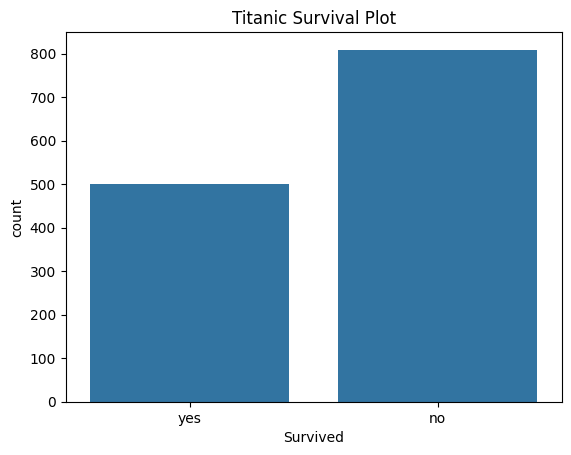

In [15]:
# ---------------------------------------
# creates a count plot showing the distribution of passengers 
# who survived vs. did not survive.
# ----------------------------------------
sns.countplot(data, x = 'Survived')
plt.title('Titanic Survival Plot') # add title to the plot
plt.show # displays the countplot

# Passenger Class

In [16]:
# ---------------------
# returns the count of unique values in 
# the 'Class' column, sorted by frequency
# ---------------------
data['Class'].value_counts()

Class
3rd    709
1st    323
2nd    277
Name: count, dtype: int64

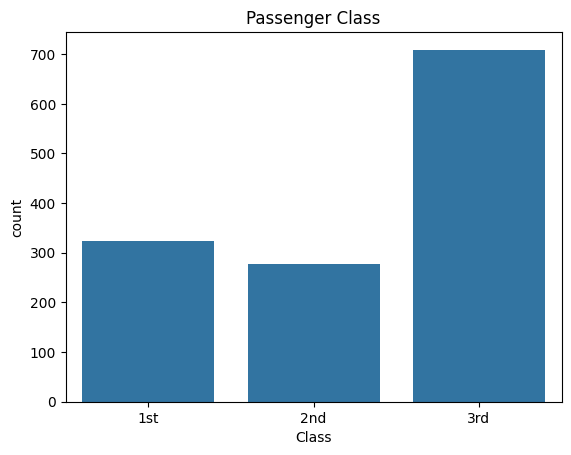

In [17]:
# ---------------------------------------
# creates a count plot showing the distribution of passenger class
# ----------------------------------------
sns.countplot(data, x = 'Class')
plt.title('Passenger Class')
plt.show()

In [18]:
# ---------------------
# Groups the dataset by 'Class' and 'Survived', 
# then counts the number of occurrences in each group.
# This shows how many passengers survived 
# or did not survive in each passenger class.
# ---------------------
data.groupby(['Class', 'Survived'])['Survived'].count()

Class  Survived
1st    no          123
       yes         200
2nd    no          158
       yes         119
3rd    no          528
       yes         181
Name: Survived, dtype: int64

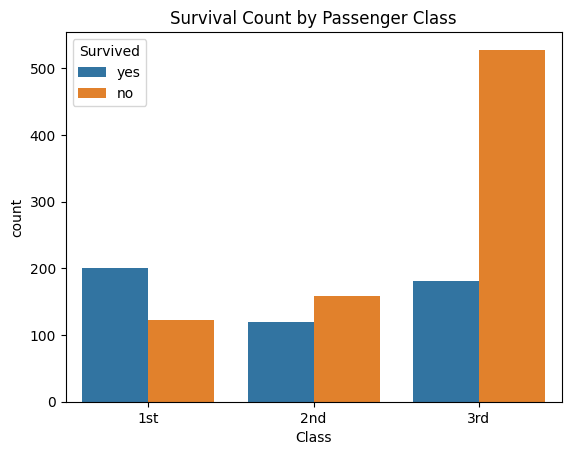

In [19]:
# ---------------------
# creates a count plot showing the number of passengers in each 'Class', 
# separated by survival status using the 'hue' parameter.
# The plot helps visualize how survival rates differ across passenger classes.
# ---------------------
sns.countplot(data, x = 'Class', hue ='Survived')
plt.title('Survival Count by Passenger Class') # adds a title to the plot
plt.show() # display plot

# Gender

In [20]:
# ---------------------
# returns the count of unique values in 
# the 'Gender' column, sorted by frequency
# ---------------------
data['Gender'].value_counts()

Gender
male      843
female    466
Name: count, dtype: int64

In [21]:
# Groups the dataset by 'Gender' and 'Survived', 
# then counts the number of occurrences of each 
# survival status within each gender.
data.groupby(['Gender', 'Survived'])['Survived'].value_counts()

Gender  Survived
female  no          127
        yes         339
male    no          682
        yes         161
Name: count, dtype: int64

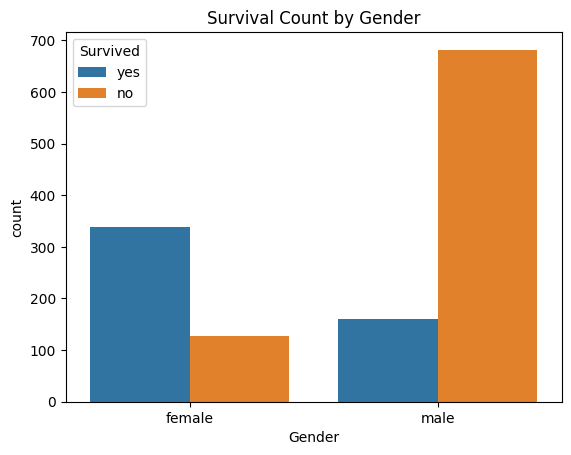

In [22]:
# ---------------------
# creates a count plot showing the number of passengers in each 'Gender', 
# separated by survival status using the 'hue' parameter.
# The plot helps visualize how survival rates differ across passenger classes.
# ---------------------
sns.countplot(data, x ='Gender', hue = 'Survived')
plt.title('Survival Count by Gender') # adds a title to the plot
plt.show() # displays the plot

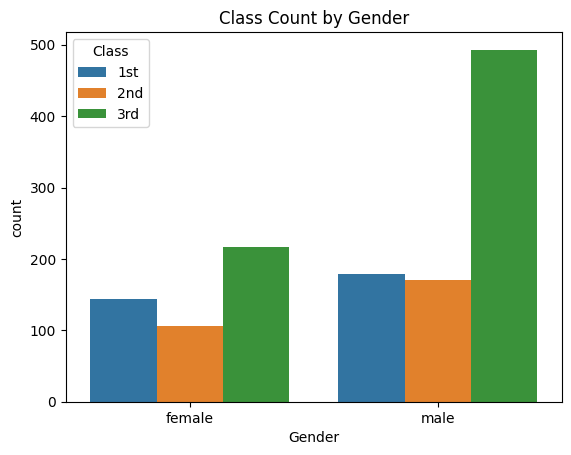

In [23]:
# ---------------------
# creates a count plot showing the number of passengers in each 'Gender', 
# separated by passenger class using the 'hue' parameter.
# The plot helps visualize how survival rates differ across passenger classes.
# ---------------------
sns.countplot(data, x ='Gender', hue = 'Class')
plt.title('Class Count by Gender')
plt.show()

# Conclusion

In summary, the EDA suggests that  <b>Gender</b>

and <b>Passenger Class</b> were the most significant factors determining survival.</b> 

<b>Female 1st Class passengers</b> would likely have the highest survival probability, 

while <b>Male 3rd Class passengers</b> would likely have the lowest.</b>

The overall fatality count was high, particularly among the 

<b>largest passenger group (3rd Class)</b> and among <b>males</b>.
